# ECE1508 - Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [4]:
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [12]:
# Task functions
from main.task import (
    CNNModel, ResNet50Model, DenseNetModel,
    load_data, load_centralized_dataset,
    train, test
)

## 2. Data Loading

Train batches: 63, Test batches: 8
Images shape: torch.Size([64, 1, 250, 90])
Labels shape: torch.Size([64])
Label values: tensor([0, 1, 2, 3, 4, 5, 6])


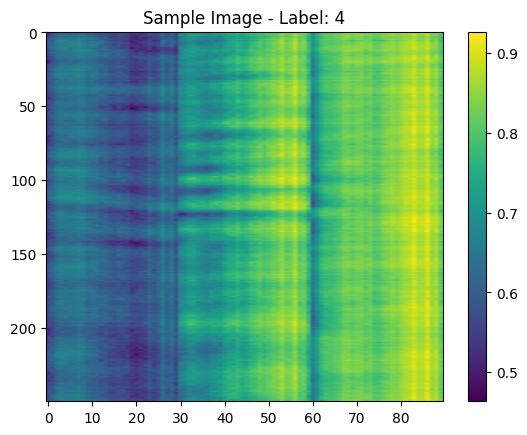

In [6]:
# Load centralized dataset (train + test)
trainloader, testloader = load_data()
print(f"Train batches: {len(trainloader)}, Test batches: {len(testloader)}")

# Check the shapes of the data
images, labels = next(iter(trainloader))
print("Images shape:", images.shape)  # Expected: [B, 1, 250, 90]
print("Labels shape:", labels.shape)
print("Label values:", labels.unique())

# Visualize a sample from the dataset
sample_image, sample_label = images[0], labels[0]
plt.imshow(sample_image.squeeze(), aspect='auto', cmap='viridis')
plt.title(f"Sample Image - Label: {sample_label.item()}")
plt.colorbar()
plt.show()

## 3. Centralized Training

In [ ]:
cnn_model = CNNModel(num_classes=7).to(DEVICE)
cnn_train_loss = train(
    net=cnn_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.01,
    device=DEVICE
)

cnn_test_loss, cnn_test_acc = test(
    net=cnn_model,
    testloader=testloader,
    device=DEVICE
)
print(f"Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_acc*100:.2f}%")

Epoch 1/5, Loss: 2.0840, Accuracy: 0.2889
Epoch 2/5, Loss: 1.7892, Accuracy: 0.2861
Epoch 3/5, Loss: 1.6445, Accuracy: 0.3633
Epoch 4/5, Loss: 1.2677, Accuracy: 0.5233
Epoch 5/5, Loss: 1.0815, Accuracy: 0.5929


In [ ]:
res_net50_model = ResNet50Model(num_classes=7).to(DEVICE)
res_train_loss_resnet = train(
    net=res_net50_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.01,
    device=DEVICE
)

res_test_loss_resnet, res_test_acc_resnet = test(
    net=res_net50_model,
    testloader=testloader,
    device=DEVICE
)
print(f"ResNet50 - Test loss: {res_test_loss_resnet:.4f}, Test accuracy: {res_test_acc_resnet*100:.2f}%")

Epoch 1/5, Loss: 2.8428, Accuracy: 0.2784


KeyboardInterrupt: 

In [11]:
dense_net_model = DenseNetModel(num_classes=7).to(DEVICE)
dense_train_loss_densenet = train(
    net=dense_net_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.01,
    device=DEVICE
)

dense_test_loss, dense_test_acc = test(
    net=dense_net_model,
    testloader=testloader,
    device=DEVICE
)
print(f"Test loss: {dense_test_loss:.4f}, Test accuracy: {dense_test_acc*100:.2f}%")

Epoch 1/5, Loss: 1.7163, Accuracy: 0.4330
Epoch 2/5, Loss: 1.1826, Accuracy: 0.5640
Epoch 3/5, Loss: 0.8797, Accuracy: 0.6872
Epoch 4/5, Loss: 0.6685, Accuracy: 0.7465
Epoch 5/5, Loss: 0.5762, Accuracy: 0.7858
Test loss: 20.8399, Test accuracy: 24.60%


## 4. Federated Learning (Decentralized)

## 5. Hierarchical Federated Learning